In [12]:
import math
from statistics import mean
import csv
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import tdt
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal
import os
from matplotlib import rcParams
import cv2
from scipy.stats import ttest_ind,ttest_rel,zscore
import scipy.io as spio


params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [13]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [14]:
### Helper functions for heart rate processing
def remove_err(hr,err):
    allowed = [0,3,4,7]
    return [x if err[i] in allowed else np.nan for i,x in enumerate(hr)]
hr_offset = 1570

def get_freq(areas):
    peak_indexes,_ = find_peaks(areas,prominence= 0.5)
    peaks = [areas[i] for i in peak_indexes]
    return len(peak_indexes)/(len(areas)/20)

def get_actual_hr(path):
    hr_scalar = 200
    err_scalar = 4
    rates = loadmat(path)['data']['response']['lickdata']
    times = [row[0] for row in rates]
    converted_hr = [x * hr_scalar for x in map_voltage([row[1] for row in rates])]
    errors = [round((x * err_scalar)) for x in map_voltage([row[2] for row in rates])]
    
    return times,converted_hr,errors

def map_voltage(rates):
    in_min = 0
    in_max = 1023
    out_min = 0
    out_max = 4.95
    return [(x - in_min) * (out_max - out_min) / (in_max - in_min) + out_min for x in rates]


In [15]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [16]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [30]:
### Get data for FigS1B
id = "000001"
date = "20221017"

csvpath = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_PupilProcessed.csv"
matpath = f"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_1.mat"

hr_times,hr,err = get_actual_hr(matpath)
hr_times = [(x-hr_offset)/1000 for x in hr_times]
hr_with_err = hr
hr = zscore(remove_err(hr,err),nan_policy="omit")
pupil_areas = []
pupilbins = []
heartbins = []
with open(csvpath, newline='') as csvfile:
    csvreader = csv.reader(csvfile)
    for row in csvreader:
        area = float(row[1])
        pupil_areas.append(area)
x = np.ndarray.tolist(np.around(np.linspace(0.05,600,(20 * 600)),3))
hr = np.interp(x,hr_times,hr)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


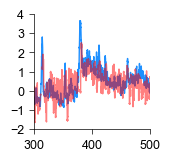

In [ ]:
### Plot FigS1B
plt.figure(figsize = (1.5,1.5))
plt.plot(x,pupil_areas,linewidth = 1,color = "dodgerblue")
plt.plot(x,hr,linewidth = 1,color  = "red",alpha = 0.5)
format_ax(plt.gca(),(300,500),(-2,4),100,1)

In [28]:
### Get data for FigS1C
id_date = {
'000001': ['20221017'],
'000002': ['20221018'],
'000006': ['20221018'],
'000007': ['20221017'],
'000008': ['20221017'],
'000017': ['20221019'],
'000018': ['20221019'],
'0000201':['20221019'],
'000028': ['20221017'],
'000029': ['20221017'],
'000030': ['20221018'],
'000031': ['20221018'],
'000032': ['20221018'],
'000033': ['20221018'],
'000035': ['20221014'],
'000036': ['20221014']
}

dict_list = []
for id,dates in id_date.items():
    for date in dates:

        csvpath = f"{base_dir}/{id}/{date}/{date}_{id}_sess_1_PupilProcessed.csv"
        matpath = f"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_1.mat"
        hr_times,hr,err = get_actual_hr(matpath)
        hr_times = [(x-hr_offset)/1000 for x in hr_times]
        hr_with_err = hr
        hr = remove_err(hr,err)
        Hr = remove_err(hr,err)
        pupil_areas = []
        with open(csvpath, newline='') as csvfile:
            csvreader = csv.reader(csvfile)
            for row in csvreader:
                area = float(row[1])
                pupil_areas.append(area)
        x = np.ndarray.tolist(np.around(np.linspace(0.05,600,(20 * 600)),3))
        interp_hr = np.interp(x,hr_times,hr_with_err)

         
        padded_hr = hr + [np.nan] * (12000-len(hr))
        z_hr = zscore(padded_hr, nan_policy = "omit")
        if(np.count_nonzero(np.isnan(hr)) < 12000):
            for hr,area in zip(z_hr,pupil_areas):
                if area > 1.5:
                    state = "dilated"
                    new_dict = {"Pupil State" : state, "Heartrate" : float(hr),"id":id,"date":date}
                    dict_list.append(new_dict)
                elif area < 0:
                    state = "constricted"
                    new_dict = {"Pupil State" : state, "Heartrate" : float(hr),"id":id,"date":date}
                    dict_list.append(new_dict)
        else:print(id + "did not pass")

hr_df = pd.DataFrame.from_dict(dict_list).dropna().groupby(["id","Pupil State"]).mean().reset_index()

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_8679/386947825.py:56: FutureWarning: The default value of numeric_only in DataFrameGroupBy.m

<Axes: xlabel='Pupil State', ylabel='Resting HR (z-scr)'>

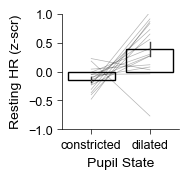

In [29]:
### Plot FigS1C
plt.figure(figsize = (1.5,1.5))
g = sns.barplot(data = hr_df, x = "Pupil State", y = "Heartrate",errorbar="se",fill = None,errwidth= 1)
g.set_ylabel("Resting HR (z-scr)")
g.set_yticks(np.arange(-1,1.5,0.5))
g.set(ylim=(-1,1))
sns.lineplot(data = hr_df, x = "Pupil State", y = "Heartrate",units = "id",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
